In [1]:
%matplotlib inline
import numpy as np
import torch
import torch.optim as optim

torch.set_printoptions(edgeitems=2, linewidth=75)

t_u: tensor([[35.7000],
        [55.9000],
        [58.2000],
        [81.9000],
        [56.3000],
        [48.9000],
        [33.9000],
        [21.8000],
        [48.4000],
        [60.4000],
        [68.4000]])
t_u: torch.Size([11, 1])
t_c: tensor([[ 0.5000],
        [14.0000],
        [15.0000],
        [28.0000],
        [11.0000],
        [ 8.0000],
        [ 3.0000],
        [-4.0000],
        [ 6.0000],
        [13.0000],
        [21.0000]])
t_c: torch.Size([11, 1])


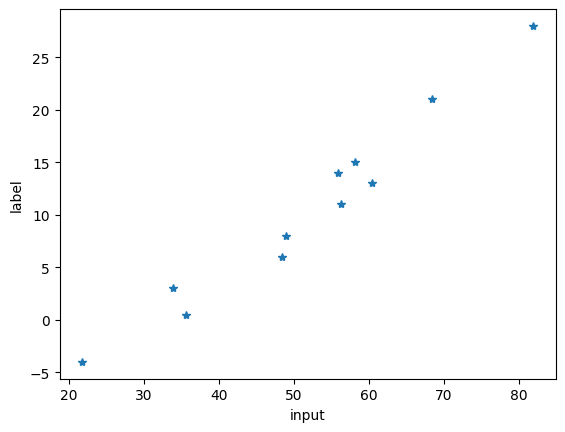

In [2]:
t_u = [35.7, 55.9, 58.2, 81.9, 56.3, 48.9, 33.9, 21.8, 48.4, 60.4, 68.4]  # 输入
t_c = [0.5, 14.0, 15.0, 28.0, 11.0, 8.0, 3.0, -4.0, 6.0, 13.0, 21.0]  # 标签值

t_u = torch.tensor(t_u).unsqueeze(1)
t_c = torch.tensor(t_c).unsqueeze(1)

print("t_u:", t_u)
print("t_u:", t_u.shape)
print("t_c:", t_c)
print("t_c:", t_c.shape)

from matplotlib import pyplot as plt

plt.plot(t_u.numpy(), t_c.numpy(), "*")
plt.xlabel("input")
plt.ylabel("label")
plt.show()

In [3]:
n_samples = t_u.shape[0]
print("n_samples:", n_samples)

n_val = int(0.2 * n_samples)
print("n_val:", n_val)

shuffled_indices = torch.randperm(n_samples)
print("shuffled_indices:", shuffled_indices)
print("shuffled_indices:", shuffled_indices.shape)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

print("train_indices:", train_indices)
print("train_indices:", train_indices.shape)
print("val_indices:", val_indices)
print("val_indices:", val_indices.shape)

n_samples: 11
n_val: 2
shuffled_indices: tensor([ 3,  5,  0,  2,  7, 10,  8,  6,  4,  1,  9])
shuffled_indices: torch.Size([11])
train_indices: tensor([ 3,  5,  0,  2,  7, 10,  8,  6,  4])
train_indices: torch.Size([9])
val_indices: tensor([1, 9])
val_indices: torch.Size([2])


In [4]:
t_u_train = t_u[train_indices]
t_c_train = t_c[train_indices]

t_u_val = t_u[val_indices]
t_c_val = t_c[val_indices]

t_un_train = 0.1 * t_u_train
t_un_val = 0.1 * t_u_val

print("t_un_train:", t_un_train)
print("t_un_train:", t_un_train.shape)
print("t_c_train:", t_c_train)
print("t_c_train:", t_c_train.shape)

print("t_un_val:", t_un_val)
print("t_un_val:", t_un_val.shape)
print("t_c_val:", t_c_val)
print("t_c_val:", t_c_val.shape)

t_un_train: tensor([[8.1900],
        [4.8900],
        [3.5700],
        [5.8200],
        [2.1800],
        [6.8400],
        [4.8400],
        [3.3900],
        [5.6300]])
t_un_train: torch.Size([9, 1])
t_c_train: tensor([[28.0000],
        [ 8.0000],
        [ 0.5000],
        [15.0000],
        [-4.0000],
        [21.0000],
        [ 6.0000],
        [ 3.0000],
        [11.0000]])
t_c_train: torch.Size([9, 1])
t_un_val: tensor([[5.5900],
        [6.0400]])
t_un_val: torch.Size([2, 1])
t_c_val: tensor([[14.],
        [13.]])
t_c_val: torch.Size([2, 1])


In [5]:
import torch.nn as nn

linear_model = nn.Linear(1, 1)  # torch.Size([2, 1]) * (1, 1)
linear_model(t_un_val)

tensor([[-4.1874],
        [-4.5281]], grad_fn=<AddmmBackward0>)

In [6]:
linear_model.weight

Parameter containing:
tensor([[-0.7569]], requires_grad=True)

In [7]:
linear_model.bias

Parameter containing:
tensor([0.0439], requires_grad=True)

In [8]:
x = torch.ones(1)
linear_model(x)

tensor([-0.7131], grad_fn=<ViewBackward0>)

In [9]:
# 为了容纳多个样本, 模块希望输入的第 0 维是批次中的样本数.
# nn 中的所有模块都被编写为可以同时为多个输入产生输出.
# 因此, 假设我们需要在 10 个样本上运行 nn.Linear, 我们可以创建一个大小为 B × Nin 的输入张量, 其中 B 是批次的大小, Nin 为输入特征的数量, 并在模型上运行一次.
x = torch.ones(10, 1)
linear_model(x)

tensor([[-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131],
        [-0.7131]], grad_fn=<AddmmBackward0>)

In [10]:
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

In [11]:
linear_model.parameters()

<generator object Module.parameters at 0x7c38fdb9eea0>

In [12]:
list(linear_model.parameters())

[Parameter containing:
 tensor([[0.2885]], requires_grad=True),
 Parameter containing:
 tensor([0.2695], requires_grad=True)]

In [13]:
def training_loop(
    n_epochs, optimizer, model, loss_fn, t_u_train, t_u_val, t_c_train, t_c_val
):
    for epoch in range(1, n_epochs + 1):
        t_p_train = model(t_u_train)
        loss_train = loss_fn(t_p_train, t_c_train)

        t_p_val = model(t_u_val)
        loss_val = loss_fn(t_p_val, t_c_val)

        optimizer.zero_grad()
        loss_train.backward()
        optimizer.step()

        if epoch == 1 or epoch % 1000 == 0:
            print(
                f"Epoch {epoch}, Training loss {loss_train.item():.4f},"
                f" Validation loss {loss_val.item():.4f}"
            )

In [14]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c) ** 2
    return squared_diffs.mean()


linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    model=linear_model,
    loss_fn=loss_fn,
    t_u_train=t_un_train,
    t_u_val=t_un_val,
    t_c_train=t_c_train,
    t_c_val=t_c_val,
)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 135.1665, Validation loss 119.7214
Epoch 1000, Training loss 3.4100, Validation loss 2.8688
Epoch 2000, Training loss 2.8853, Validation loss 3.1975
Epoch 3000, Training loss 2.8769, Validation loss 3.2406

Parameter containing:
tensor([[5.4128]], requires_grad=True)
Parameter containing:
tensor([-17.4377], requires_grad=True)


In [15]:
# 使用 nn.MSELoss 损失函数
linear_model = nn.Linear(1, 1)
optimizer = optim.SGD(linear_model.parameters(), lr=1e-2)

training_loop(
    n_epochs=3000,
    optimizer=optimizer,
    model=linear_model,
    loss_fn=nn.MSELoss(),
    t_u_train=t_un_train,
    t_u_val=t_un_val,
    t_c_train=t_c_train,
    t_c_val=t_c_val,
)

print()
print(linear_model.weight)
print(linear_model.bias)

Epoch 1, Training loss 249.7020, Validation loss 255.7373
Epoch 1000, Training loss 3.4203, Validation loss 2.8653
Epoch 2000, Training loss 2.8855, Validation loss 3.1970
Epoch 3000, Training loss 2.8769, Validation loss 3.2405

Parameter containing:
tensor([[5.4128]], requires_grad=True)
Parameter containing:
tensor([-17.4373], requires_grad=True)


In [16]:
seq_model = nn.Sequential(
    nn.Linear(
        1, 13
    ),  # 我们随便指定输出张量的大小为 13, 我们是想该张量的大小与其他张量的形状大小不一样.
    nn.Tanh(),
    nn.Linear(13, 1),  # 这里的张量形状大小值 13 必须与前一个模块输出张量的大小相等.
)
seq_model

Sequential(
  (0): Linear(in_features=1, out_features=13, bias=True)
  (1): Tanh()
  (2): Linear(in_features=13, out_features=1, bias=True)
)

In [17]:
[param.shape for param in seq_model.parameters()]

[torch.Size([13, 1]), torch.Size([13]), torch.Size([1, 13]), torch.Size([1])]

In [18]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

# (11, 1) * (1, 13) = (11, 13)
# (11, 13) + (13,) = (11, 13)
# (11, 13) * (13, 1) = (11, 1)
# (11, 1) + (1,) = (11, 1)

0.weight torch.Size([13, 1])
0.bias torch.Size([13])
2.weight torch.Size([1, 13])
2.bias torch.Size([1])


In [19]:
from collections import OrderedDict

seq_model = nn.Sequential(
    OrderedDict(
        [
            ("hidden_linear", nn.Linear(1, 8)),
            ("hidden_activation", nn.Tanh()),
            ("output_linear", nn.Linear(8, 1)),
        ]
    )
)

seq_model

Sequential(
  (hidden_linear): Linear(in_features=1, out_features=8, bias=True)
  (hidden_activation): Tanh()
  (output_linear): Linear(in_features=8, out_features=1, bias=True)
)

In [20]:
for name, param in seq_model.named_parameters():
    print(name, param.shape)

# (11, 1) * (1, 8) = (11, 8)
# (11, 8) + (8,) = (11, 8)
# (11, 8) * (8, 1) = (11, 1)
# (11, 1) + (1,) = (11, 1)

hidden_linear.weight torch.Size([8, 1])
hidden_linear.bias torch.Size([8])
output_linear.weight torch.Size([1, 8])
output_linear.bias torch.Size([1])


In [21]:
print("seq_model.hidden_linear.weight:", seq_model.hidden_linear.weight)
print("seq_model.hidden_linear.bias:", seq_model.hidden_linear.bias)
print("seq_model.output_linear.weight:", seq_model.output_linear.weight)
print("seq_model.output_linear.bias:", seq_model.output_linear.bias)

seq_model.hidden_linear.weight: Parameter containing:
tensor([[ 0.3578],
        [-0.4936],
        [ 0.6435],
        [-0.2844],
        [-0.9704],
        [-0.4710],
        [-0.0499],
        [ 0.0506]], requires_grad=True)
seq_model.hidden_linear.bias: Parameter containing:
tensor([ 0.5492, -0.0916,  0.7155, -0.1118,  0.0007,  0.5856, -0.2356,
         0.2071], requires_grad=True)
seq_model.output_linear.weight: Parameter containing:
tensor([[-0.1143,  0.2344, -0.0625, -0.0262, -0.2899,  0.1712, -0.2059,
          0.3104]], requires_grad=True)
seq_model.output_linear.bias: Parameter containing:
tensor([-0.1456], requires_grad=True)


In [22]:
optimizer = optim.SGD(seq_model.parameters(), lr=1e-3)

training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    model=seq_model,
    loss_fn=nn.MSELoss(),
    t_u_train=t_un_train,
    t_u_val=t_un_val,
    t_c_train=t_c_train,
    t_c_val=t_c_val,
)

# 模型训练之后, 可以使用模型进行推理
print("output", seq_model(t_un_val))
print("answer", t_c_val)
print("hidden", seq_model.hidden_linear.weight.grad)

Epoch 1, Training loss 191.4760, Validation loss 186.9396
Epoch 1000, Training loss 5.1867, Validation loss 3.7495
Epoch 2000, Training loss 3.0637, Validation loss 4.5190
Epoch 3000, Training loss 1.7516, Validation loss 4.7501
Epoch 4000, Training loss 1.3140, Validation loss 4.7976
Epoch 5000, Training loss 1.2378, Validation loss 4.8544
output tensor([[12.2867],
        [15.7563]], grad_fn=<AddmmBackward0>)
answer tensor([[14.],
        [13.]])
hidden tensor([[-0.1855],
        [ 0.3718],
        [-0.0807],
        [ 9.0319],
        [ 0.0426],
        [ 9.5214],
        [ 8.9447],
        [-9.3589]])


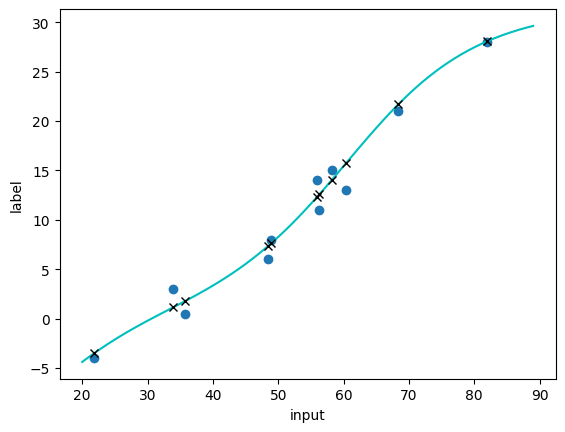

In [23]:
from matplotlib import pyplot as plt

t_range = torch.arange(20.0, 90.0).unsqueeze(1)

plt.plot(t_u.numpy(), t_c.numpy(), "o")
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), "c-")
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), "kx")
plt.xlabel("input")
plt.ylabel("label")

plt.show()

Epoch 1, Training loss 188.3380, Validation loss 181.1151
Epoch 1000, Training loss 64.8465, Validation loss 8.9319
Epoch 2000, Training loss 38.8221, Validation loss 3.4410
Epoch 3000, Training loss 21.3949, Validation loss 1.7728
Epoch 4000, Training loss 11.7931, Validation loss 1.9973
Epoch 5000, Training loss 7.3060, Validation loss 2.7440


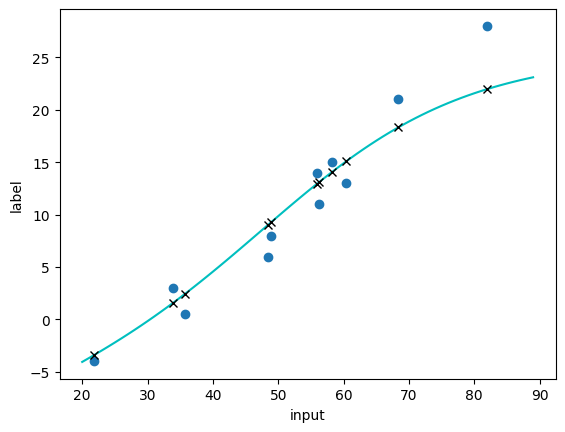

In [24]:
neuron_count = 20

seq_model = nn.Sequential(
    OrderedDict(
        [
            ("hidden_linear", nn.Linear(1, neuron_count)),
            ("hidden_activation", nn.Tanh()),
            ("output_linear", nn.Linear(neuron_count, 1)),
        ]
    )
)

optimizer = optim.SGD(seq_model.parameters(), lr=1e-4)

training_loop(
    n_epochs=5000,
    optimizer=optimizer,
    model=seq_model,
    loss_fn=nn.MSELoss(),
    t_u_train=t_un_train,
    t_u_val=t_un_val,
    t_c_train=t_c_train,
    t_c_val=t_c_val,
)

from matplotlib import pyplot as plt

t_range = torch.arange(20.0, 90.0).unsqueeze(1)

plt.plot(t_u.numpy(), t_c.numpy(), "o")
plt.plot(t_range.numpy(), seq_model(0.1 * t_range).detach().numpy(), "c-")
plt.plot(t_u.numpy(), seq_model(0.1 * t_u).detach().numpy(), "kx")
plt.xlabel("input")
plt.ylabel("label")

plt.show()